# Analysis of the results for several exp

I have to chqnge the phenotyp eso thqt it diesnt cqlculqte dom qgqin for the elites
implement different type of mutqtion for elite ie less frequent or not... 
implement continuous dominance and new ways to change it 
write down everything i have done 
add section comment to file txt and if not calculate then no change in elite possible if i want to mutate then continuous is far better si je reussis bien j qugmente la dominance un peu si et sinon je diminue par le bas

In [2]:
import os 
import json 
import dill 
import matplotlib.pyplot as plt
import numpy as np
import sys

from base_fns import get_local_file
file = get_local_file()

local_dir = os.path.dirname(os.path.dirname(file))
sys.path.append(local_dir)


def add_env_switch_lines(config, generations, label='env switch'):
    """Trace une ligne verticale a chaque generation de changement d'env.
    Ne fait rien si 'switch' n'est pas dans le config (safe pour les expes a env fixe)."""
    if 'switch' not in config:
        return
    switch = config['switch']
    max_gen = int(np.max(generations))
    for j, g in enumerate(range(switch, max_gen + 1, switch)):
        plt.axvline(x=g, color='grey', linestyle='--', alpha=0.65,
                    label=label if j == 0 else None)

## How to use

Please change the direction of the results you want to analyze :  

In [3]:
# to change 
path = 'changingenv10'
number = 1
# end of to change 

results_dir = os.path.join(local_dir, 'results', '{}'.format(path), 'id_{}'.format(number))
haploid_dir = os.path.join(results_dir, 'haploid')
diploid_dir = os.path.join(results_dir, 'diploid')
json_haploid_dir = os.path.join(haploid_dir, 'json')
json_diploid_dir = os.path.join(diploid_dir, 'json')
file = 'configs.json'
haploid_json_dir_file = os.path.join(json_haploid_dir, file)
diploid_json_dir_file = os.path.join(json_diploid_dir, file)
with open(haploid_json_dir_file, 'r') as f : 
    haploid_data_config = json.load(f)

result = ''
for key, value in haploid_data_config.items():
    result += f'{key} : {value}\n'

with open(diploid_json_dir_file, 'r') as f : 
    diploid_data_config = json.load(f)

diploid_result = ''
for key, value in diploid_data_config.items():
    diploid_result += f'{key} : {value}\n'


print(result)
print(diploid_result)




number_of_exp : 2
number_of_config : 1
threshold_var : 0.15
body_shape : [5, 5]
max_weight : 1
max_bias : 1
response : 1
max_weight_cppn : 20
max_bias_cppn : 20
range_weight : 1
range_bias : 1
sigma_weight : 0.1
sigma_bias : 0.1
sigma_dominance : 0.15
threshold_weight : 0.05
threshold_bias : 0.03
threshold_function : 0.03
threshold_dominance : 0.07
switch : 30
generations : 330
population : 128
number_of_winner : 1
number_in_tournament : 3
number_of_elites : 2
shape_of_cppn : [[11], [5], [3, 3], [1, 1]]
function_pool : ['gaussian', 'sin', 'tanh']
n_steps : [1000, 600]
number_of_reported_individuals : 40
cpus : 32
env_name : ['Pusher-v0', 'Walker-v0']

number_of_exp : 2
number_of_config : 1
threshold_var : 0.15
body_shape : [5, 5]
max_weight : 1
max_bias : 1
response : 1
max_weight_cppn : 20
max_bias_cppn : 20
range_weight : 1
range_bias : 1
sigma_weight : 0.1
sigma_bias : 0.1
sigma_dominance : 0.15
threshold_weight : 0.05
threshold_bias : 0.03
threshold_function : 0.03
threshold_domina

number_of_exp : 2
number_of_config : 1
threshold_var : 0.15
body_shape : [5, 5]
max_weight : 1
max_bias : 1
response : 1
max_weight_cppn : 20
max_bias_cppn : 20
range_weight : 1
range_bias : 1
sigma_weight : 0.1
sigma_bias : 0.1
sigma_dominance : 0.15
threshold_weight : 0.05
threshold_bias : 0.03
threshold_function : 0.03
threshold_dominance : 0.07
switch : 30
generations : 330
population : 128
number_of_winner : 1
number_in_tournament : 3
number_of_elites : 2
shape_of_cppn : [[11], [5], [3, 3], [1, 1]]
function_pool : ['gaussian', 'sin', 'tanh']
n_steps : [1000, 600]
number_of_reported_individuals : 40
cpus : 32
env_name : ['Pusher-v0', 'Walker-v0']


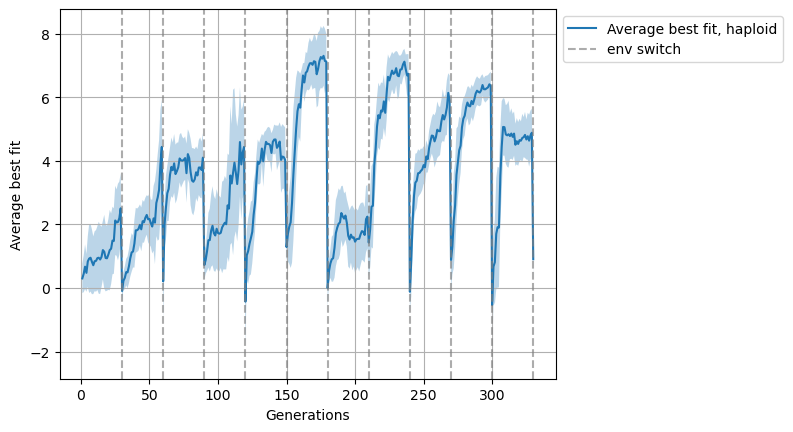

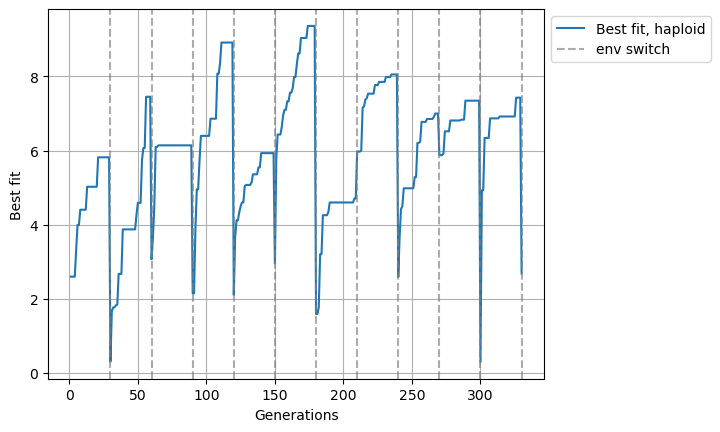

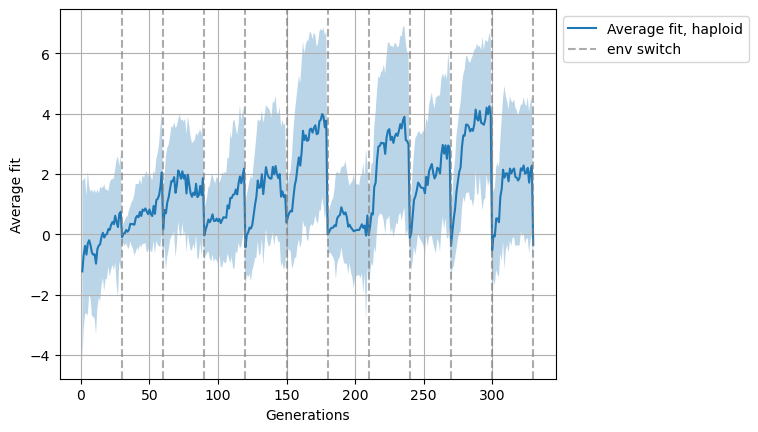

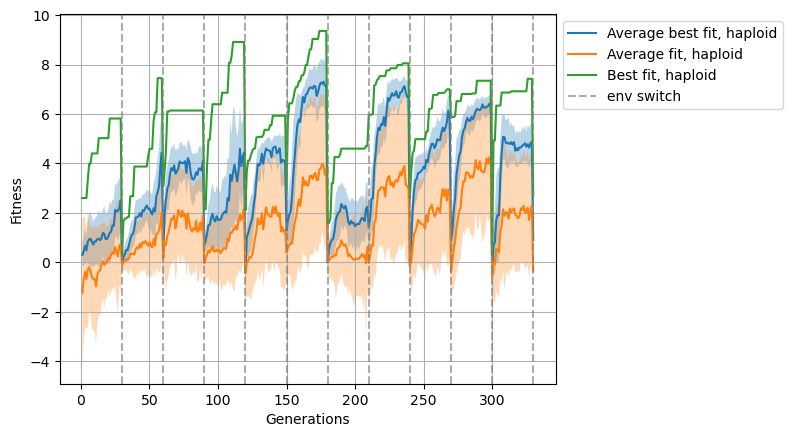

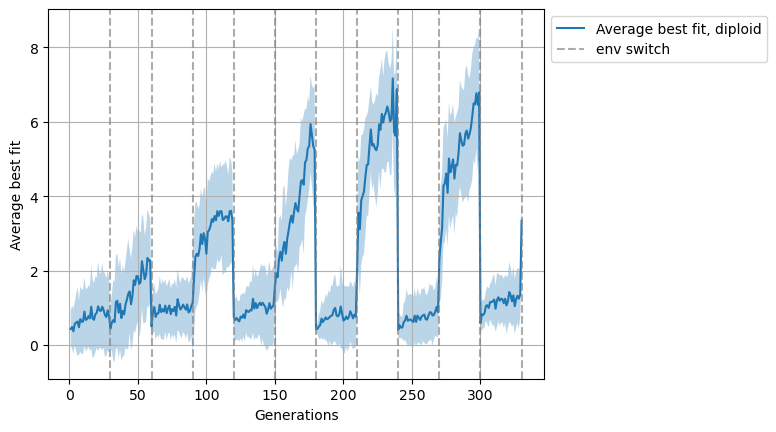

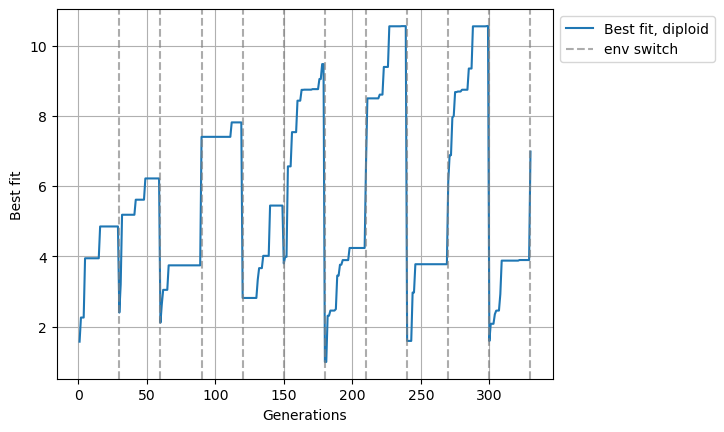

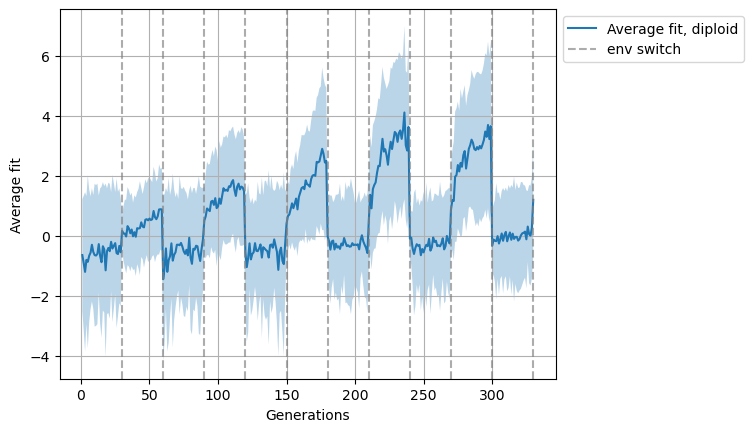

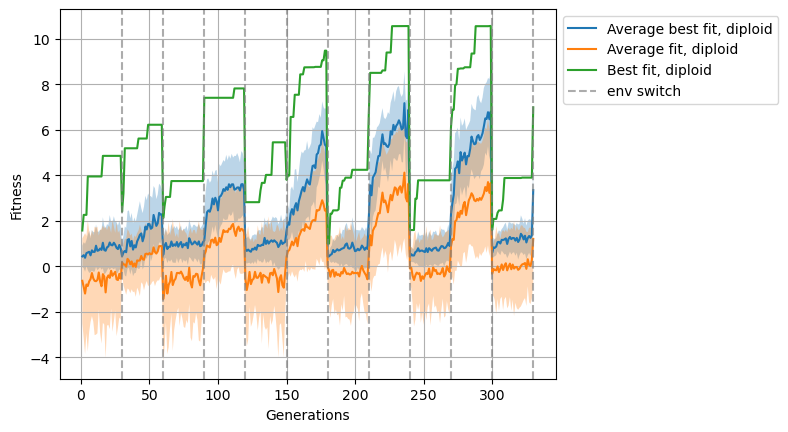

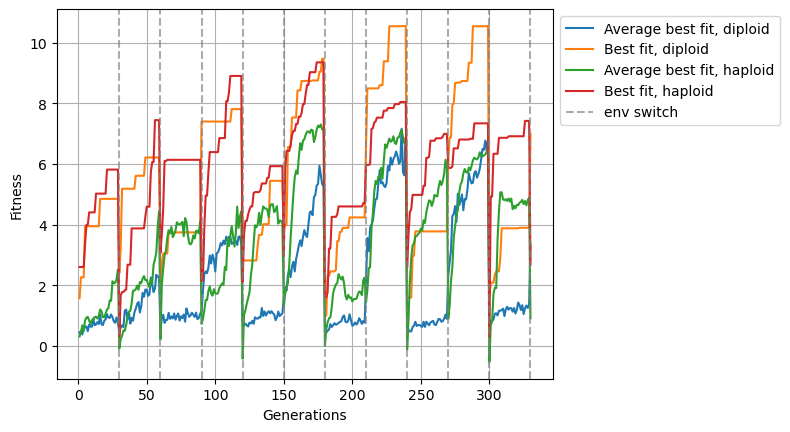

number_of_exp : 2
number_of_config : 1
threshold_var : 0.15
body_shape : [5, 5]
max_weight : 1
max_bias : 1
response : 1
max_weight_cppn : 20
max_bias_cppn : 20
range_weight : 1
range_bias : 1
sigma_weight : 0.1
sigma_bias : 0.1
sigma_dominance : 0.15
threshold_weight : 0.05
threshold_bias : 0.03
threshold_function : 0.03
threshold_dominance : 0.07
switch : 30
generations : 330
population : 128
number_of_winner : 1
number_in_tournament : 3
number_of_elites : 2
shape_of_cppn : [[11], [5], [3, 3], [1, 1]]
function_pool : ['gaussian', 'sin', 'tanh']
n_steps : [1000, 600]
number_of_reported_individuals : 40
cpus : 32
env_name : ['Pusher-v0', 'Walker-v0']


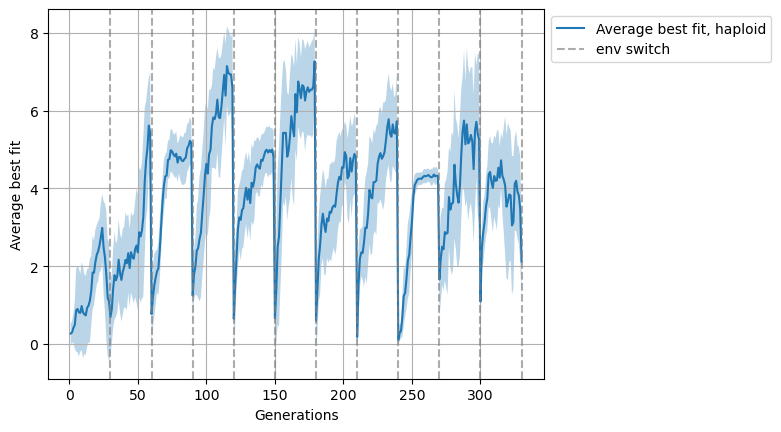

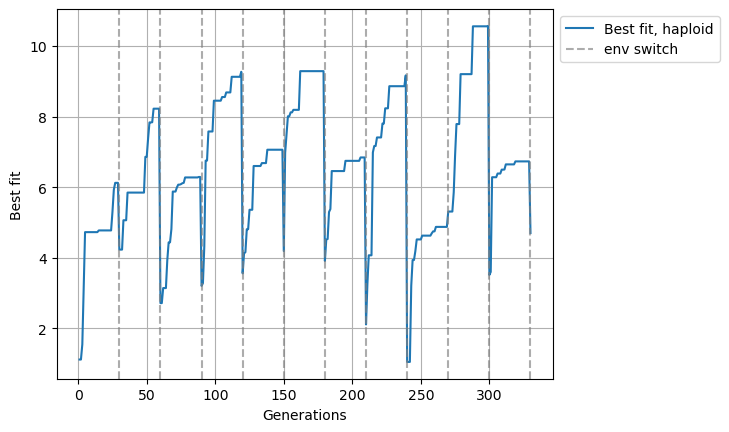

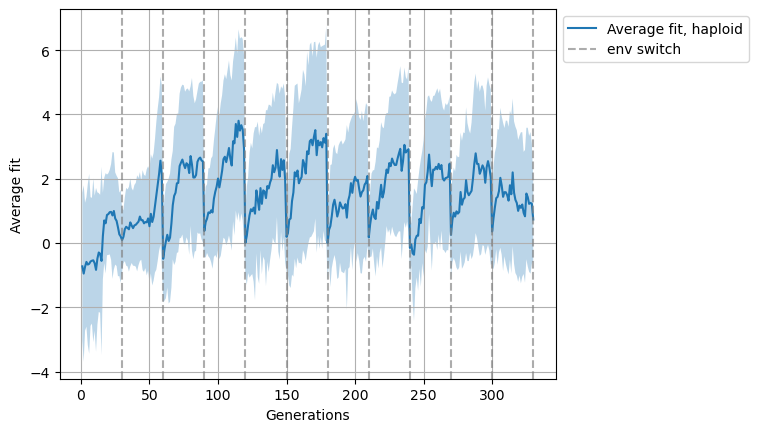

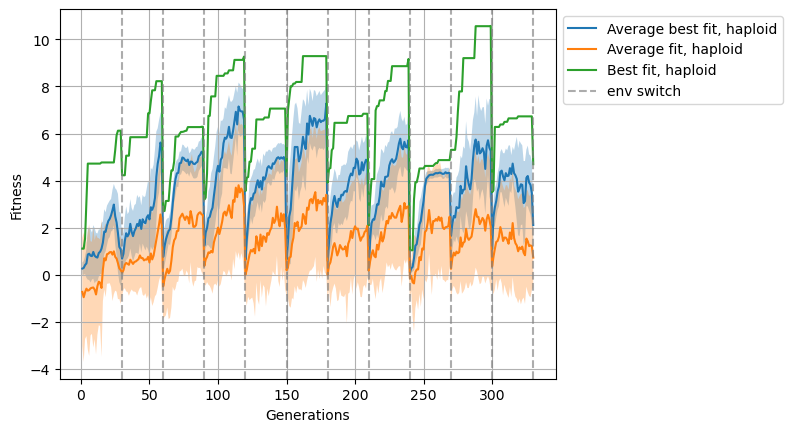

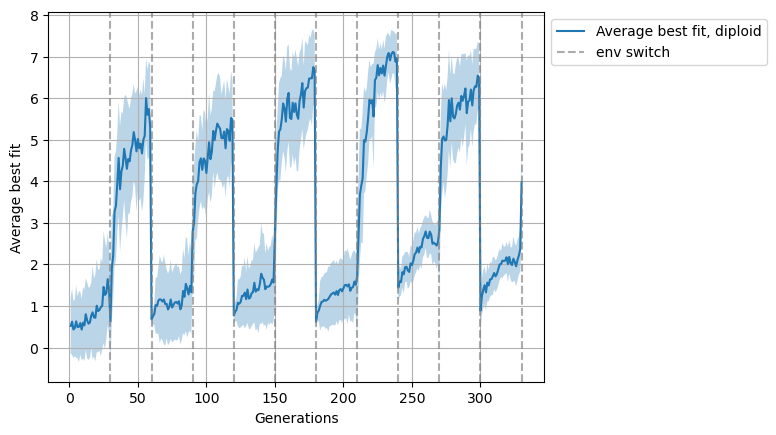

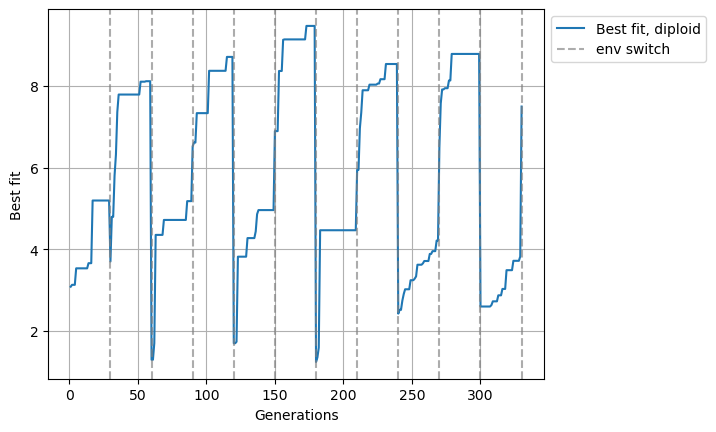

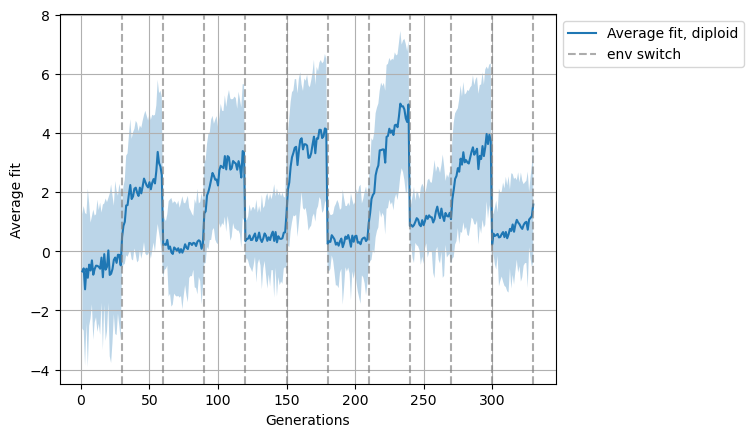

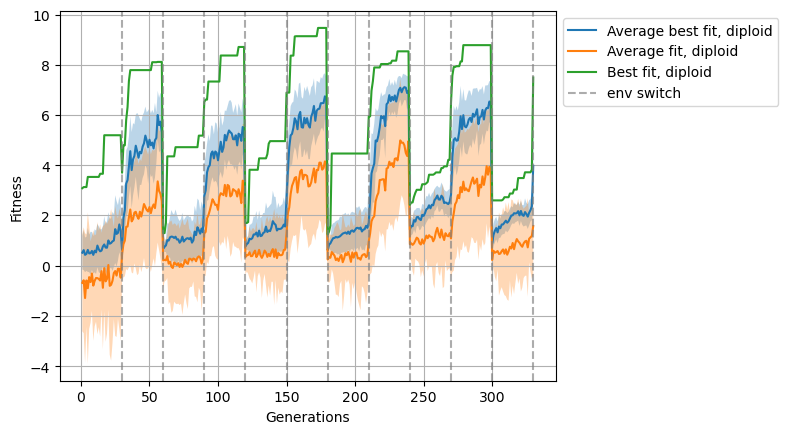

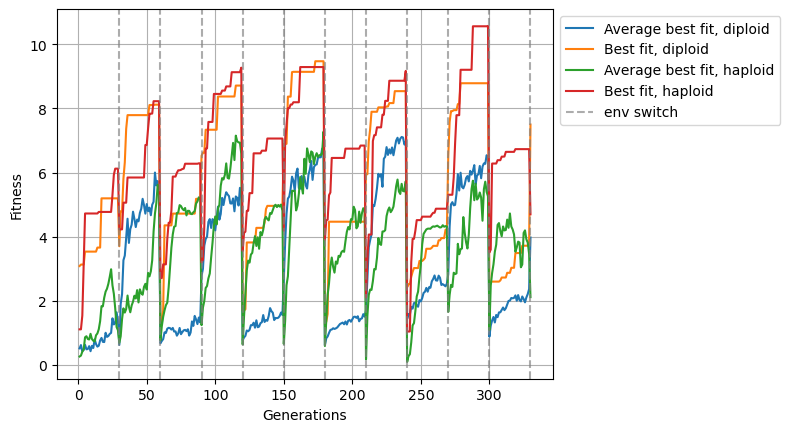

In [4]:
general_best_haploid = []
general_average_bests_haploid = []
general_best_diploid = []
general_average_bests_diploid = []


for k in range(haploid_data_config['number_of_config']) : 
    general_best_haploid_sigma = []
    general_average_bests_haploid_sigma = []
    general_best_diploid_sigma = []
    general_average_bests_diploid_sigma = []
    for i in range(diploid_data_config['number_of_exp']) :
        id_exp = number + k * diploid_data_config['number_of_exp'] + i
        results_dir = os.path.join(local_dir, 'results', '{}'.format(path), 'id_{}'.format(id_exp))
        haploid_dir = os.path.join(results_dir, 'haploid')
        diploid_dir = os.path.join(results_dir, 'diploid')
        current_json_dir = os.path.join(haploid_dir, 'json')
        current_json_file = os.path.join(current_json_dir, 'configs.json')
        with open(current_json_file, 'r') as f : 
            data_config = json.load(f)
        
        for key, value in data_config.items():
            print(f'{key} : {value}')


        pkl_dir = os.path.join(haploid_dir, 'pkl')
        for file in os.listdir(pkl_dir) : 
            if file.endswith('statistic_registry.pkl') :
                file_dir = os.path.join(pkl_dir, file)
                with open(file_dir, 'rb') as f :
                    loaded_file = dill.load(f)

        generations = []
        averages = []
        stds = []
        bests = []
        fitnesses = []
        average_bests = []
        stds_bests = []


        for statistic in loaded_file.values() :
            generations.append(statistic.generation)
            averages.append(statistic.average)
            stds.append(statistic.std)
            bests.append(statistic.best)
            fitnesses.append(statistic.fitness)
            average_bests.append(statistic.average_best)
            stds_bests.append(statistic.std_best)

        general_best_haploid_sigma.append(fitnesses)
        general_average_bests_haploid_sigma. append(average_bests)

        generations = np.array(generations)
        averages = np.array(averages)
        stds = np.array(stds)
        bests = np.array(bests)
        fitnesses = np.array(fitnesses)
        average_bests = np.array(average_bests)
        stds_bests = np.array(stds_bests)
        fig = plt.figure()
        

        plt.plot(generations, average_bests, label = 'Average best fit, haploid')
        plt.fill_between(generations, average_bests - stds_bests, average_bests + stds_bests, alpha = 0.3)
        plt.xlabel('Generations')
        plt.ylabel('Average best fit')
        plt.grid(True, which = 'both')
        add_env_switch_lines(data_config, generations)
        plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
        plt.show()

        plt.plot(generations, fitnesses, label = 'Best fit, haploid')
        plt.xlabel('Generations')
        plt.ylabel('Best fit')
        plt.grid(True, which = 'both')
        add_env_switch_lines(data_config, generations)
        plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
        plt.show()

        plt.plot(generations, averages, label = 'Average fit, haploid')
        plt.fill_between(generations, averages - stds, averages + stds, alpha = 0.3)
        plt.xlabel('Generations')
        plt.ylabel('Average fit')
        plt.grid(True, which = 'both')
        add_env_switch_lines(data_config, generations)
        plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
        plt.show()

        plt.plot(generations, average_bests, label = 'Average best fit, haploid')
        plt.fill_between(generations, average_bests - stds_bests, average_bests + stds_bests, alpha = 0.3)
        plt.plot(generations, averages, label = 'Average fit, haploid')
        plt.fill_between(generations, averages - stds, averages + stds, alpha = 0.3)
        plt.plot(generations, fitnesses, label = 'Best fit, haploid')
        plt.xlabel('Generations')
        plt.ylabel('Fitness')
        plt.grid(True, which = 'both')
        add_env_switch_lines(data_config, generations)
        plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
        plt.show()

        pkl_dir = os.path.join(diploid_dir, 'pkl')
        for file in os.listdir(pkl_dir) : 
            if file.endswith('statistic_registry.pkl') :
                file_dir = os.path.join(pkl_dir, file)
                with open(file_dir, 'rb') as f :
                    loaded_file = dill.load(f)

        generations = []
        averages = []
        stds = []
        bests = []
        diploid_fitnesses = []
        diploid_average_bests = []
        diploid_stds_bests = []


        for statistic in loaded_file.values() :
            generations.append(statistic.generation)
            averages.append(statistic.average)
            stds.append(statistic.std)
            bests.append(statistic.best)
            diploid_fitnesses.append(statistic.fitness)
            diploid_average_bests.append(statistic.average_best)
            diploid_stds_bests.append(statistic.std_best)

        general_best_diploid_sigma.append(diploid_fitnesses)
        general_average_bests_diploid_sigma. append(diploid_average_bests)

        generations = np.array(generations)
        averages = np.array(averages)
        stds = np.array(stds)
        bests = np.array(bests)
        diploid_fitnesses = np.array(diploid_fitnesses)
        diploid_average_bests = np.array(diploid_average_bests)
        diploid_stds_bests = np.array(diploid_stds_bests)

        plt.plot(generations, diploid_average_bests, label = 'Average best fit, diploid')
        plt.fill_between(generations, diploid_average_bests - diploid_stds_bests, diploid_average_bests + diploid_stds_bests, alpha = 0.3)
        plt.xlabel('Generations')
        plt.ylabel('Average best fit')
        plt.grid(True, which = 'both')
        add_env_switch_lines(data_config, generations)
        plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
        plt.show()

        plt.plot(generations, diploid_fitnesses, label = 'Best fit, diploid')
        plt.xlabel('Generations')
        plt.ylabel('Best fit')
        plt.grid(True, which = 'both')
        add_env_switch_lines(data_config, generations)
        plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
        plt.show()

        plt.plot(generations, averages, label = 'Average fit, diploid')
        plt.fill_between(generations, averages - stds, averages + stds, alpha = 0.3)
        plt.xlabel('Generations')
        plt.ylabel('Average fit')
        plt.grid(True, which = 'both')
        add_env_switch_lines(data_config, generations)
        plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
        plt.show()

        plt.plot(generations, diploid_average_bests, label = 'Average best fit, diploid')
        plt.fill_between(generations, diploid_average_bests - diploid_stds_bests, diploid_average_bests + diploid_stds_bests, alpha = 0.3)
        plt.plot(generations, averages, label = 'Average fit, diploid')
        plt.fill_between(generations, averages - stds, averages + stds, alpha = 0.3)
        plt.plot(generations, diploid_fitnesses, label = 'Best fit, diploid')
        plt.xlabel('Generations')
        plt.ylabel('Fitness')
        plt.grid(True, which = 'both')
        add_env_switch_lines(data_config, generations)
        plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
        plt.show()

        plt.plot(generations, diploid_average_bests, label = 'Average best fit, diploid')
        plt.plot(generations, diploid_fitnesses, label = 'Best fit, diploid')
        plt.plot(generations, average_bests, label = 'Average best fit, haploid')
        plt.plot(generations, fitnesses, label = 'Best fit, haploid')
        plt.xlabel('Generations')
        plt.ylabel('Fitness')
        plt.grid(True, which = 'both')
        add_env_switch_lines(data_config, generations)
        plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
        plt.show()   
    
    general_average_bests_haploid.append(general_average_bests_haploid_sigma)
    general_average_bests_diploid.append(general_average_bests_diploid_sigma)
    general_best_haploid.append(general_best_haploid_sigma)
    general_best_diploid.append(general_best_diploid_sigma)

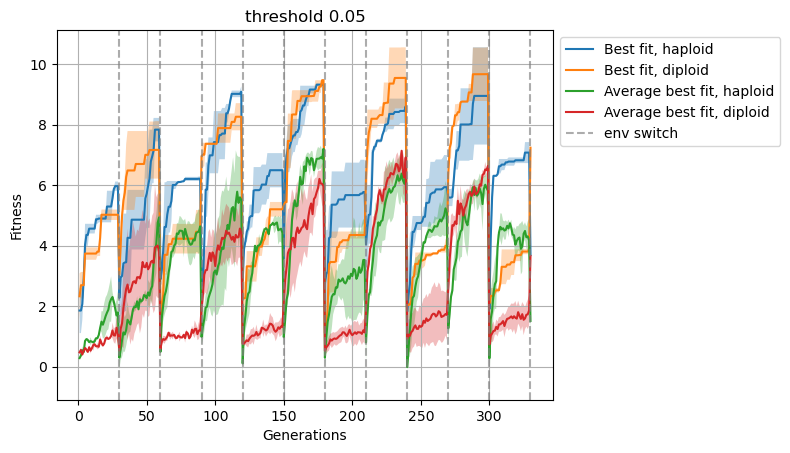

In [5]:
for i in range(haploid_data_config['number_of_config']) :
    threshold = haploid_data_config['threshold_weight'] + i * haploid_data_config['threshold_var']
    general_best_haploid = np.array(general_best_haploid)
    general_average_bests_haploid = np.array(general_average_bests_haploid)
    general_best_diploid = np.array(general_best_diploid)
    general_average_bests_diploid = np.array(general_average_bests_diploid)

    mean_general_best_haploid = np.mean(general_best_haploid[i], axis = 0)
    mean_general_average_bests_haploid = np.mean(general_average_bests_haploid[i], axis = 0)
    mean_general_best_diploid = np.mean(general_best_diploid[i], axis = 0)
    mean_general_average_bests_diploid = np.mean(general_average_bests_diploid[i], axis = 0)

    std_general_best_haploid = np.std(general_best_haploid[i], axis = 0)
    std_general_average_bests_haploid = np.std(general_average_bests_haploid[i], axis = 0)
    std_general_best_diploid = np.std(general_best_diploid[i], axis = 0)
    std_general_average_bests_diploid = np.std(general_average_bests_diploid[i], axis = 0)

    plt.figure()
    plt.title('threshold {:.2f}'.format(threshold))

    plt.plot(generations, mean_general_best_haploid, label = 'Best fit, haploid')
    plt.fill_between(generations, mean_general_best_haploid - std_general_best_haploid, mean_general_best_haploid + std_general_best_haploid, alpha = 0.3)
    plt.plot(generations, mean_general_best_diploid, label = 'Best fit, diploid')
    plt.fill_between(generations, mean_general_best_diploid - std_general_best_diploid, mean_general_best_diploid + std_general_best_diploid, alpha = 0.3)
    plt.plot(generations, mean_general_average_bests_haploid, label = 'Average best fit, haploid')
    plt.fill_between(generations, mean_general_average_bests_haploid - std_general_average_bests_haploid, mean_general_average_bests_haploid + std_general_average_bests_haploid, alpha = 0.3)
    plt.plot(generations, mean_general_average_bests_diploid, label = 'Average best fit, diploid')
    plt.fill_between(generations, mean_general_average_bests_diploid - std_general_average_bests_diploid, mean_general_average_bests_diploid + std_general_average_bests_diploid, alpha = 0.3)
    plt.xlabel('Generations')
    plt.ylabel('Fitness')
    plt.grid(True, which = 'both')
    add_env_switch_lines(haploid_data_config, generations)
    plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
    plt.show()

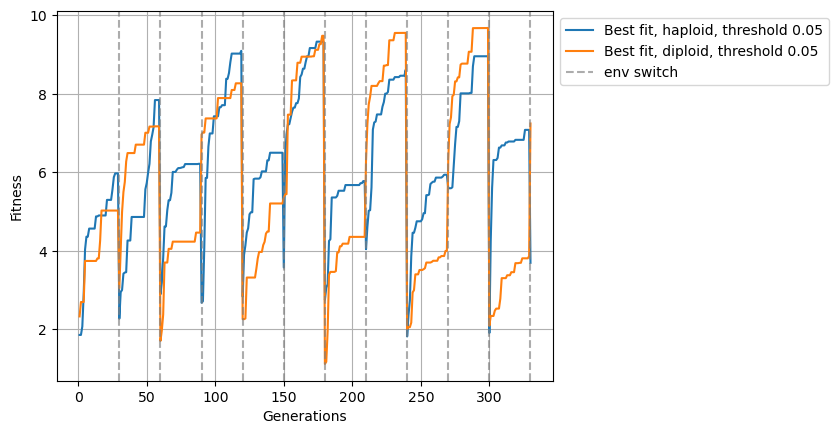

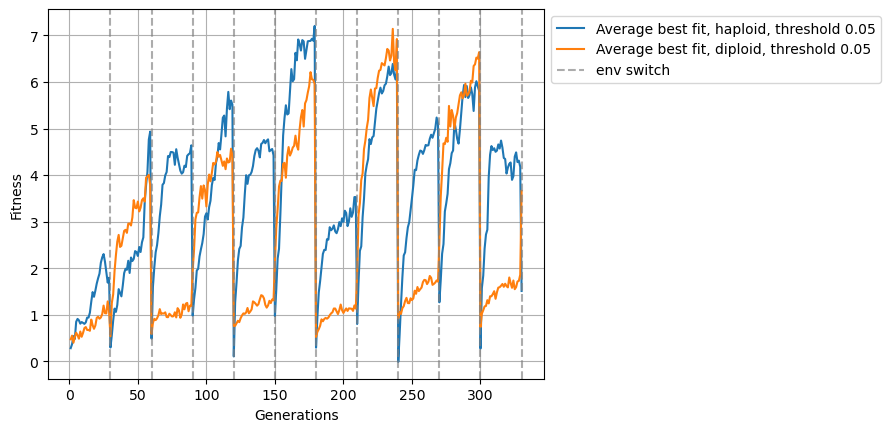

In [6]:
fig = plt.figure()
for i in range(haploid_data_config['number_of_config']) :
    threshold = haploid_data_config['threshold_weight'] + i * haploid_data_config['threshold_var']
    plt.plot(generations, np.mean(general_best_haploid[i], axis = 0), label = 'Best fit, haploid, threshold {:.2f}'.format(threshold))
    plt.plot(generations, np.mean(general_best_diploid[i], axis = 0), label = 'Best fit, diploid, threshold {:.2f}'.format(threshold))
plt.xlabel('Generations')
plt.ylabel('Fitness')
plt.grid(True, which = 'both')
add_env_switch_lines(haploid_data_config, generations)
plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
plt.show()


fig = plt.figure()
for i in range(haploid_data_config['number_of_config']) :
    threshold = haploid_data_config['threshold_weight'] + i * haploid_data_config['threshold_var']
    plt.plot(generations, np.mean(general_average_bests_haploid[i], axis = 0), label = 'Average best fit, haploid, threshold {:.2f}'.format(threshold))
    plt.plot(generations, np.mean(general_average_bests_diploid[i], axis = 0), label = 'Average best fit, diploid, threshold {:.2f}'.format(threshold))
plt.xlabel('Generations')
plt.ylabel('Fitness')
plt.grid(True, which = 'both')
add_env_switch_lines(haploid_data_config, generations)
plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
plt.show()